# Notebook Goal

Understand how cells move over time in the ground-truth annotations before building a tracker.

The notebook answers:

How far do cells typically move?
Are movements small enough for nearest-neighbor tracking?
Are there unusual movements that require special handling?

In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from src.analysis.movement_statistics import analyze_movement, plot_movement_histogram
from src.data.dataloader import BioHubDataset


In [15]:
dataset = BioHubDataset("../data/raw/train")
stats = analyze_movement(dataset)
print(f"Average : {stats.average:.2f} µm")
print(f"Minimum : {stats.minimum:.2f} µm")
print(f"Maximum : {stats.maximum:.2f} µm")
print(f"Samples : {len(stats.displacements)}")

Average : 2.13 µm
Minimum : 0.00 µm
Maximum : 60.76 µm
Samples : 128883


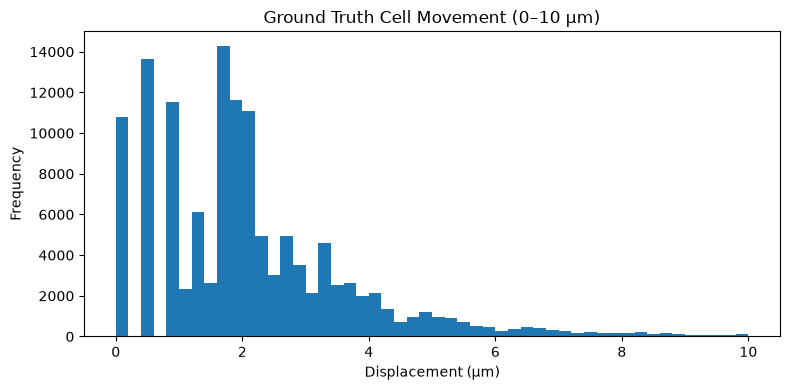

In [16]:
plot_movement_histogram(stats)

In [17]:
sample = dataset["6bba_786893ac"]

lookup = {
    node.id: node
    for node in sample.nodes
}

deltas = []

for edge in sample.edges:
    source = lookup[edge.source_id]
    target = lookup[edge.target_id]

    deltas.append(target.t - source.t)

set(deltas)

{1}

In [18]:
import numpy as np

d = np.array(stats.displacements)

print("50th:", np.percentile(d, 50))
print("90th:", np.percentile(d, 90))
print("95th:", np.percentile(d, 95))
print("99th:", np.percentile(d, 99))

50th: 1.8168052317185792
90th: 4.1429533547941375
95th: 5.343384490423649
99th: 8.384905522723557


In [33]:
import src.analysis.movement_statistics as ms

import importlib
importlib.reload(ms)

<module 'src.analysis.movement_statistics' from '/Users/axstormx/Downloads/kaggle-competition/biohub-cell-tracking/src/analysis/movement_statistics.py'>

In [24]:
print(ms.__file__)
print("MovementExample" in dir(ms))
print("largest_movements" in dir(ms))
largest = ms.largest_movements(dataset)

largest

/Users/axstormx/Downloads/kaggle-competition/biohub-cell-tracking/src/analysis/movement_statistics.py
True
True


[MovementExample(distance=60.758487061479734, sample_name='6bba_f20478e9', edge=Edge(source_id=65000869, target_id=66000881), source=Node(id=65000869, t=64, z=11, y=152, x=27, confidence=1.0), target=Node(id=66000881, t=65, z=46, y=100, x=35, confidence=1.0)),
 MovementExample(distance=60.17164575715874, sample_name='6bba_f20478e9', edge=Edge(source_id=66000880, target_id=67000885), source=Node(id=66000880, t=65, z=44, y=155, x=101, confidence=1.0), target=Node(id=67000885, t=66, z=7, y=150, x=98, confidence=1.0)),
 MovementExample(distance=58.53666385800441, sample_name='6bba_f20478e9', edge=Edge(source_id=66000882, target_id=67000887), source=Node(id=66000882, t=65, z=60, y=171, x=199, confidence=1.0), target=Node(id=67000887, t=66, z=24, y=166, x=200, confidence=1.0)),
 MovementExample(distance=56.933006134403264, sample_name='6bba_f20478e9', edge=Edge(source_id=66000881, target_id=67000894), source=Node(id=66000881, t=65, z=46, y=100, x=35, confidence=1.0), target=Node(id=67000894,

In [36]:
sample = dataset["6bba_786893ac"]
print(sample.edges)

(Edge(source_id=1000011, target_id=2000061), Edge(source_id=1000013, target_id=2000064), Edge(source_id=1000014, target_id=2000066), Edge(source_id=1000017, target_id=2000070), Edge(source_id=1000018, target_id=2000071), Edge(source_id=1000021, target_id=2000076), Edge(source_id=1000023, target_id=2000088), Edge(source_id=1000029, target_id=2000086), Edge(source_id=1000030, target_id=2000084), Edge(source_id=1000033, target_id=2000089), Edge(source_id=1000035, target_id=2000092), Edge(source_id=1000040, target_id=2000099), Edge(source_id=1000041, target_id=2000096), Edge(source_id=1000043, target_id=2000095), Edge(source_id=1000044, target_id=2000100), Edge(source_id=1000046, target_id=2000101), Edge(source_id=1000049, target_id=2000104), Edge(source_id=2000061, target_id=3000116), Edge(source_id=2000064, target_id=3000120), Edge(source_id=2000066, target_id=3000121), Edge(source_id=2000070, target_id=3000126), Edge(source_id=2000071, target_id=3000127), Edge(source_id=2000076, target_

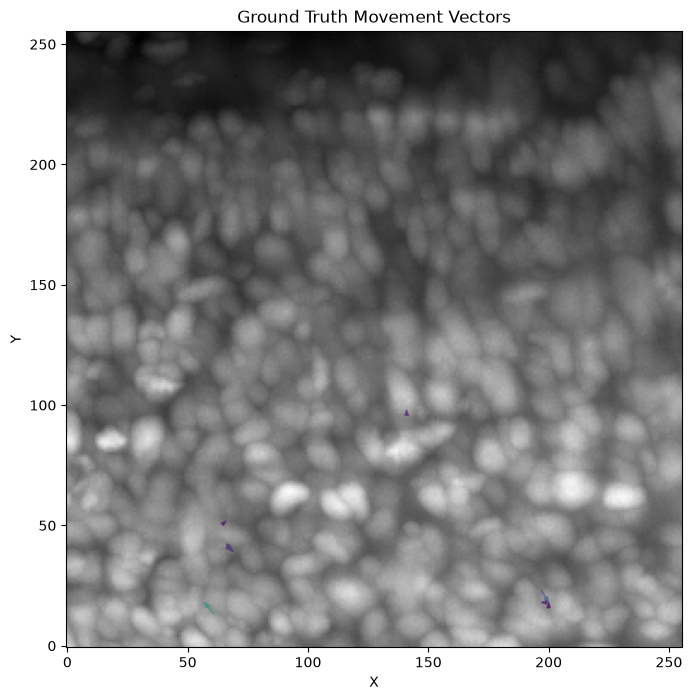

In [37]:

ms.plot_movement_vectors(sample, z=31)

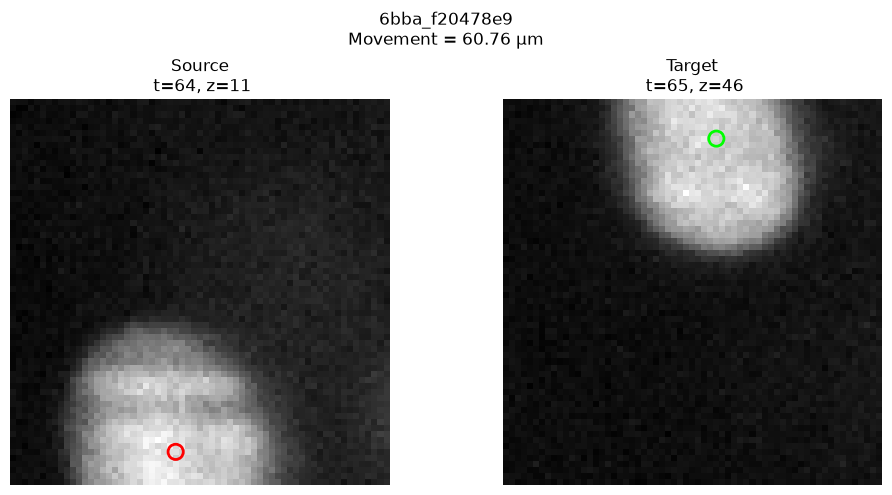

In [38]:
ms.visualize_movement_example(
    dataset,
    largest[0],
)

In [39]:
largest = ms.largest_movements(dataset)

for movement in largest:
    print(movement.sample_name)
    print(ms.axis_displacement(movement.source, movement.target))

6bba_f20478e9
{'dx_um': 3.25, 'dy_um': 21.125, 'dz_um': 56.875}
6bba_f20478e9
{'dx_um': 1.21875, 'dy_um': 2.03125, 'dz_um': 60.125}
6bba_f20478e9
{'dx_um': 0.40625, 'dy_um': 2.03125, 'dz_um': 58.5}
6bba_f20478e9
{'dx_um': 0.8125, 'dy_um': 2.4375, 'dz_um': 56.875}
6bba_f20478e9
{'dx_um': 2.4375, 'dy_um': 16.25, 'dz_um': 50.375}
6bba_f20478e9
{'dx_um': 1.21875, 'dy_um': 17.46875, 'dz_um': 47.125}
6bba_f20478e9
{'dx_um': 2.4375, 'dy_um': 15.4375, 'dz_um': 47.125}
6bba_f20478e9
{'dx_um': 2.84375, 'dy_um': 6.5, 'dz_um': 48.75}
6bba_e5e44988
{'dx_um': 2.84375, 'dy_um': 25.59375, 'dz_um': 6.5}
6bba_e5e44988
{'dx_um': 0.40625, 'dy_um': 23.5625, 'dz_um': 9.75}


In [28]:
movement = largest[0]

print(movement.source)
print(movement.target)

print(
    "Δx =", movement.target.x - movement.source.x,
    "Δy =", movement.target.y - movement.source.y,
    "Δz =", movement.target.z - movement.source.z,
)

Node(id=65000869, t=64, z=11, y=152, x=27, confidence=1.0)
Node(id=66000881, t=65, z=46, y=100, x=35, confidence=1.0)
Δx = 8 Δy = -52 Δz = 35


In [29]:
summary = ms.summarize_movement(stats)

for key, value in summary.items():
    print(f"{key:>6}: {value:.2f}")

  mean: 2.13
median: 1.82
   std: 1.79
   p90: 4.14
   p95: 5.34
   p99: 8.38
   max: 60.76


In [40]:
sample = dataset["6bba_f20478e9"]

print(len(sample.nodes))
print(len(sample.edges))

1003
963


In [41]:
lookup = {node.id: node for node in sample.nodes}

large_z = 0

for edge in sample.edges:
    source = lookup[edge.source_id]
    target = lookup[edge.target_id]

    if abs(target.z - source.z) > 20:
        large_z += 1

print(large_z)

8


# Final conclusions

Ground-truth edges always connect consecutive frames (Δt = 1).
Typical cell movement is small (≈2 µm).
95% of movements are below 5.34 µm.
Extreme movements are rare, concentrated in one sample, and largely due to Z-axis changes.
Therefore, a nearest-neighbor tracker with a search radius based on the movement distribution (rather than the maximum) is a well-supported baseline.